# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Diệp Thời Hậu"  # TODO: Họ và tên
STUDENT_ID = "2452324"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Diệp Thời Hậu (2452324)


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\Downloads\PYML(HW)\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [5]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...

row_max = np.max(logits, axis=1, keepdims=True)
shifted_logits = logits - row_max

exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

print("shifted logits:\n", shifted_logits)
print("class_probabilities:\n", np.round(class_probabilities, 4))
print("predicted_classes:", predicted_classes)
print("confidence_scores:", np.round(confidence_scores, 4))


shifted logits:
 [[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
class_probabilities:
 [[0.659  0.2424 0.0986]
 [0.2447 0.6652 0.09  ]
 [0.0066 0.0179 0.9756]
 [0.3333 0.3333 0.3333]]
predicted_classes: [0 1 2 0]
confidence_scores: [0.659  0.6652 0.9756 0.3333]


In [6]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [7]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [9]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...

train_feature_mean = X_train.mean(axis=0)

train_feature_std = X_train.std(axis=0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std

X_val_scaled = (X_val - train_feature_mean) / train_feature_std

print("train_feature_mean:", train_feature_mean)
print("train_feature_std:", train_feature_std)

print("\nX_train_scaled:")
print(np.round(X_train_scaled, 3))

print("\nX_val_scaled:")
print(np.round(X_val_scaled, 3))

train_feature_mean: [172.5         69.16666667   1.65        28.16666667]
train_feature_std: [ 7.47774476 13.04372987  0.79109629  7.64671316]

X_train_scaled:
[[-0.334 -0.319 -0.569 -0.806]
 [ 1.003  0.831  0.948  0.894]
 [-1.672 -1.469 -1.074 -1.199]
 [ 0.334  0.064 -0.19  -0.022]
 [-0.602 -0.703 -0.822 -0.545]
 [ 1.27   1.597  1.706  1.678]]

X_val_scaled:
[[-0.067 -0.089 -0.316 -0.283]
 [ 2.34   1.981  2.212  2.201]]


In [10]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [11]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [12]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...

correct_mask = predicted_classes == true_labels

high_confidence_mask = confidence_scores >= confidence_threshold

review_mask = (~correct_mask) | (~high_confidence_mask)

review_indices = np.where(review_mask)[0]

print("correct_mask:", correct_mask)
print("high_confidence_mask:", high_confidence_mask)
print("review_mask:", review_mask)
print("review_indices:", review_indices)

correct_mask: [ True False  True False]
high_confidence_mask: [False False  True False]
review_mask: [ True  True False  True]
review_indices: [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [13]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [14]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...

normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

augmented_batch = normalized_batch[:, :, ::-1, :].copy()

augmented_batch[0, 0, 0, 0] = 1.0

print("normalized_batch dtype:", normalized_batch.dtype)
print("normalized_batch min:", normalized_batch.min())
print("normalized_batch max:", normalized_batch.max())
print("augmented_batch shape:", augmented_batch.shape)
print("augmented_batch[0, 0, 0, 0]:", augmented_batch[0, 0, 0, 0])

normalized_batch dtype: float32
normalized_batch min: 0.0
normalized_batch max: 0.37254903
augmented_batch shape: (2, 4, 4, 3)
augmented_batch[0, 0, 0, 0]: 1.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports
2. Ký hiệu missing value trong CSV là dấu ?.
3. `symboling` có ý nghĩa là mức đánh giá rủi ro bảo hiểm của xe, có giá trị từ -3 đến 3.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [23]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...

raw_df = pd.read_csv(DATA_PATH)

raw_shape = raw_df.shape

raw_missing_marker_count = (raw_df == "?").sum().sum()

print("raw_shape:", raw_shape)
print("raw_missing_marker_count:", raw_missing_marker_count)

display(raw_df.head())
display(raw_df.dtypes)

raw_shape: (205, 26)
raw_missing_marker_count: 59


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


symboling              int64
normalized_losses     object
make                  object
fuel_type             object
aspiration            object
num_doors             object
body_style            object
drive_wheels          object
engine_location       object
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type           object
num_cylinders         object
engine_size            int64
fuel_system           object
bore                  object
stroke                object
compression_ratio    float64
horsepower            object
peak_rpm              object
city_mpg               int64
highway_mpg            int64
price                 object
dtype: object

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [24]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [25]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...

df_clean = raw_df.replace("?", np.nan).copy()

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

missing_by_column = df_clean.isna().sum().sort_values(ascending=False)

print("các cột có missing values:")
display(missing_by_column[missing_by_column > 0])

print("dtype sau khi xử lý:")
display(df_clean.dtypes)

các cột có missing values:


normalized_losses    41
stroke                4
price                 4
bore                  4
horsepower            2
peak_rpm              2
num_doors             2
dtype: int64

dtype sau khi xử lý:


symboling              int64
normalized_losses    float64
make                  object
fuel_type             object
aspiration            object
num_doors             object
body_style            object
drive_wheels          object
engine_location       object
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type           object
num_cylinders         object
engine_size            int64
fuel_system           object
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
Không nên fill tất cả numeric columns bằng cùng một giá trị vì mỗi cột có đơn vị và ý nghĩa khác nhau. Ví dụ price là USD, horsepower là hp, còn highway_mpg là miles per gallon. Nếu dùng chung một giá trị để điền, dữ liệu có thể bị méo và làm sai thống kê.

Với price trong bài EDA này nên drop các dòng thiếu vì price là biến phân tích chính và chỉ thiếu 4 dòng. Nếu fill price bằng mean hoặc median, phân phối giá và mối liên hệ giữa giá với các biến khác có thể bị làm sai.

normalized_losses thiếu 41 giá trị, nhiều hơn hẳn các cột khác. Vì vậy nếu phân tích cột này thì số dòng hợp lệ sẽ giảm nhiều, hoặc nếu fill dữ liệu thì kết quả có thể bị thiên lệch.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [26]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [27]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...

analysis_df = df_clean[AUTO_FEATURES].dropna().copy()

X_auto = analysis_df.to_numpy(dtype=np.float64)

auto_feature_mean = X_auto.mean(axis=0)

auto_feature_std = X_auto.std(axis=0)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("analysis_df shape:", analysis_df.shape)
print("X_auto shape:", X_auto.shape)

print("\nauto_feature_mean:")
print(np.round(auto_feature_mean, 3))

print("\nauto_feature_std:")
print(np.round(auto_feature_std, 3))

print("\nX_auto_scaled mean:")
print(np.round(X_auto_scaled.mean(axis=0), 4))

print("\nX_auto_scaled std:")
print(np.round(X_auto_scaled.std(axis=0), 4))

analysis_df shape: (199, 6)
X_auto shape: (199, 6)

auto_feature_mean:
[ 2556.03    126.824   103.397    25.201    30.683 13243.432]

auto_feature_std:
[5.185480e+02 4.164800e+01 3.745900e+01 6.436000e+00 6.832000e+00
 7.958635e+03]

X_auto_scaled mean:
[ 0.  0.  0. -0.  0. -0.]

X_auto_scaled std:
[1. 1. 1. 1. 1. 1.]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [28]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...

price_index = AUTO_FEATURES.index("price")

price_z = X_auto_scaled[:, price_index]

price_outlier_mask = np.abs(price_z) > 2

price_outliers = analysis_df.loc[price_outlier_mask].copy()

price_outliers["price_z"] = price_z[price_outlier_mask]

print("số outlier theo price:", price_outlier_mask.sum())

display(price_outliers.sort_values("price", ascending=False))

số outlier theo price: 14


,curb_weight,engine_size,horsepower,city_mpg,highway_mpg,price,price_z
74,3715,304,184.0,14,16,45400.0,4.040463
16,3380,209,182.0,16,22,41315.0,3.527184
73,3900,308,184.0,14,16,40960.0,3.482578
128,2800,194,207.0,17,25,37028.0,2.988523
17,3505,209,182.0,15,20,36880.0,2.969927
49,3950,326,262.0,13,17,36000.0,2.859356
48,4066,258,176.0,15,19,35550.0,2.802813
72,3685,234,155.0,16,18,35056.0,2.740742
71,3740,234,155.0,16,18,34184.0,2.631176
127,2756,194,207.0,17,25,34028.0,2.611574


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [30]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...

engine_size_index = AUTO_FEATURES.index("engine_size")
price_index = AUTO_FEATURES.index("price")

engine_price_corr = np.corrcoef(X_auto[:, engine_size_index],X_auto[:, price_index])[0, 1]

price_by_body_style = (
    df_clean
    .dropna(subset=["price"])
    .groupby("body_style")["price"]
    .mean()
    .sort_values(ascending=False)
)

print("crrelation engine_size - price:", round(engine_price_corr, 4))

display(price_by_body_style)

crrelation engine_size - price: 0.8739


body_style
hardtop        22208.500000
convertible    21890.500000
sedan          14459.755319
wagon          12371.960000
hatchback       9957.441176
Name: price, dtype: float64

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

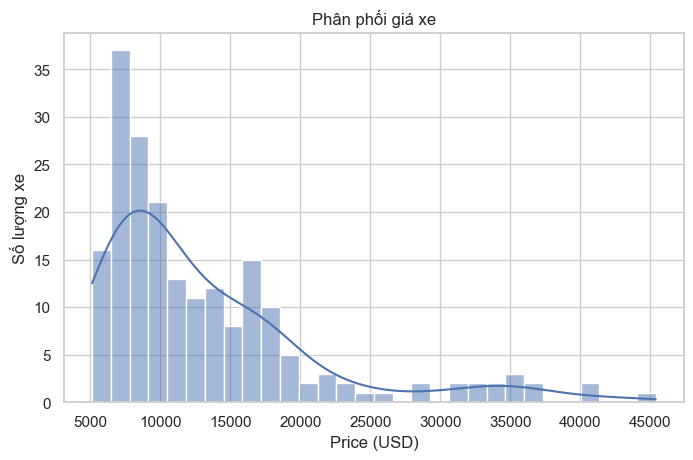

Mean price: 13207.13
Median price: 10295.0
Max price: 45400.0


In [31]:
# TODO M2.1: histogram/KDE của price
price_data = df_clean["price"].dropna()

plt.figure(figsize=(8, 4.8))

sns.histplot(price_data, bins=30, kde=True)

plt.title("Phân phối giá xe")
plt.xlabel("Price (USD)")
plt.ylabel("Số lượng xe")

plt.show()

print("Mean price:", round(price_data.mean(), 2))
print("Median price:", price_data.median())
print("Max price:", price_data.max())

**Nhận xét:** <!-- 1--2 câu -->

## M2.2 Dataset có cân bằng theo body style không?

In [ ]:
# TODO M2.2: countplot của body_style

**Nhận xét:** <!-- 1--2 câu -->

## M2.3 Price khác nhau theo body style ra sao?

In [ ]:
# TODO M2.3: boxplot price theo body_style

**Nhận xét:** <!-- 1--2 câu -->

## M2.4 Engine size liên quan thế nào tới price?

In [ ]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type

**Nhận xét:** <!-- 1--2 câu -->

## M2.5 Các feature numeric tương quan ra sao?

In [ ]:
# TODO M2.5: correlation heatmap

**Nhận xét:** <!-- 1--2 câu -->

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

In [ ]:
# TODO M2.6: biểu đồ tự chọn

**Nhận xét:** <!-- 1--2 câu -->

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->